In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\ATHAR\Downloads\pwskills\HR Analytics\raw data\training_and_development_data.csv")
df.head()

,Employee ID,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost
0,1001,21-Sep-22,Customer Service,Internal,Failed,Port Greg,Amanda Daniels,4,510.83
1,1002,19-Jul-23,Leadership Development,Internal,Failed,Brandonview,Brittany Chambers,2,582.37
2,1003,24-Feb-23,Technical Skills,Internal,Incomplete,Port Briannahaven,Mark Roberson,4,777.06
3,1004,12-Jan-23,Customer Service,Internal,Completed,Knightborough,Richard Fisher,2,824.30
4,1005,12-May-23,Communication Skills,External,Passed,Bruceshire,Heather Shaffer,4,145.99


In [3]:
df.shape

(3000, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee ID              3000 non-null   int64  
 1   Training Date            3000 non-null   object 
 2   Training Program Name    3000 non-null   object 
 3   Training Type            3000 non-null   object 
 4   Training Outcome         3000 non-null   object 
 5   Location                 3000 non-null   object 
 6   Trainer                  3000 non-null   object 
 7   Training Duration(Days)  3000 non-null   int64  
 8   Training Cost            3000 non-null   float64
dtypes: float64(1), int64(2), object(6)
memory usage: 211.1+ KB


In [5]:
df.isnull().sum()

Employee ID                0
Training Date              0
Training Program Name      0
Training Type              0
Training Outcome           0
Location                   0
Trainer                    0
Training Duration(Days)    0
Training Cost              0
dtype: int64

In [6]:
# df.isnull().mean() * 100

Employee ID                0.0
Training Date              0.0
Training Program Name      0.0
Training Type              0.0
Training Outcome           0.0
Location                   0.0
Trainer                    0.0
Training Duration(Days)    0.0
Training Cost              0.0
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['Employee ID', 'Training Date', 'Training Program Name',
       'Training Type', 'Training Outcome', 'Location', 'Trainer',
       'Training Duration(Days)', 'Training Cost'],
      dtype='object')

In [9]:
df['Training Date'] = pd.to_datetime(df['Training Date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Employee ID              3000 non-null   int64         
 1   Training Date            3000 non-null   datetime64[ns]
 2   Training Program Name    3000 non-null   object        
 3   Training Type            3000 non-null   object        
 4   Training Outcome         3000 non-null   object        
 5   Location                 3000 non-null   object        
 6   Trainer                  3000 non-null   object        
 7   Training Duration(Days)  3000 non-null   int64         
 8   Training Cost            3000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 211.1+ KB


In [11]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [12]:
df.columns

Index(['employee_id', 'training_date', 'training_program_name',
       'training_type', 'training_outcome', 'location', 'trainer',
       'training_duration(days)', 'training_cost'],
      dtype='object')

In [13]:
# EDA

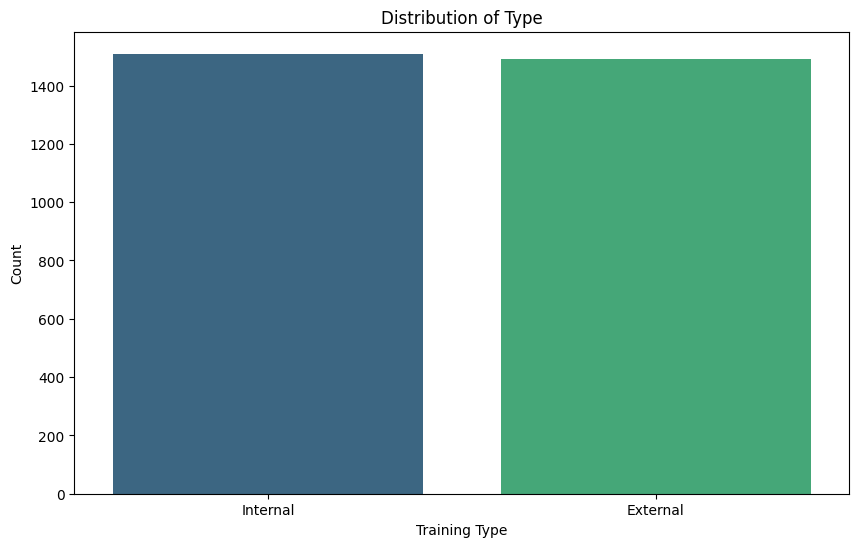

In [37]:
plt.figure(figsize=(10,6))
sns.countplot(data= df ,x = 'training_type', hue= 'training_type',palette='viridis')
plt.title('Distribution of Type')
plt.xlabel('Training Type')
plt.ylabel('Count')
plt.show()

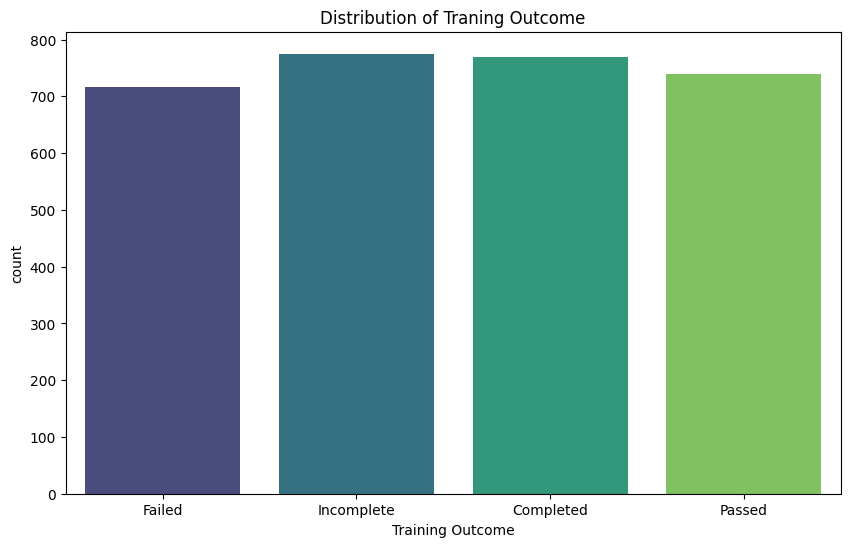

In [35]:
plt.figure(figsize=(10,6))
sns.countplot(data= df ,x = 'training_outcome', hue= 'training_outcome',palette='viridis', legend=False)
plt.title('Distribution of Traning Outcome')
plt.xlabel('Training Outcome')
plt.ylabel('count')
plt.show()

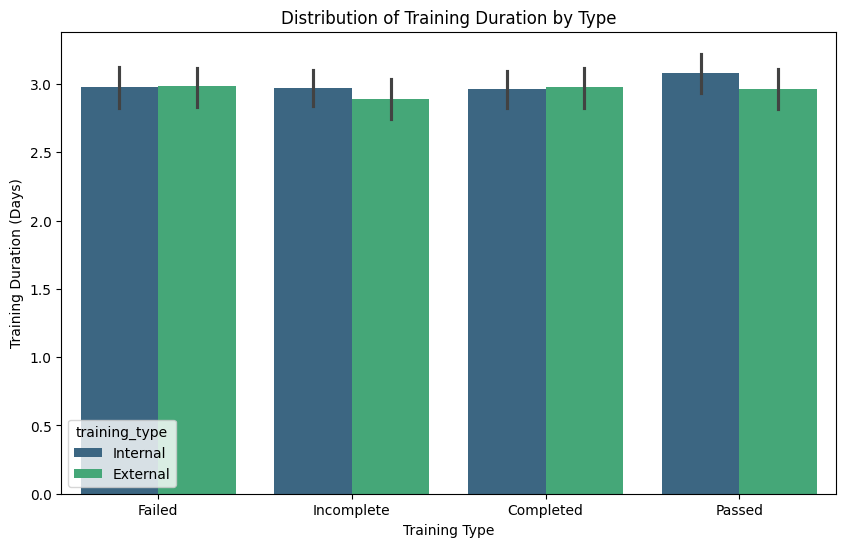

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(data= df ,x = 'training_outcome', y = 'training_duration(days)', hue= 'training_type',palette='viridis')
plt.title('Distribution of Training Duration by Type')
plt.xlabel('Training Type')
plt.ylabel('Training Duration (Days)')
plt.show()

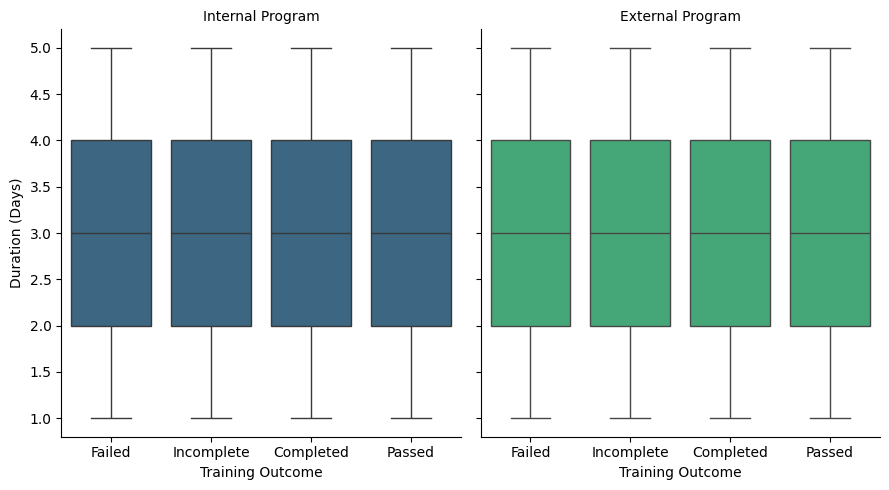

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Splits data into unique side-by-side charts for each Training Type
g = sns.FacetGrid(df, col="training_type", height=5, aspect=0.9, hue="training_type", palette="viridis")

# Maps a standard boxplot layout inside each individual column
g.map_dataframe(sns.boxplot, x="training_outcome", y="training_duration(days)")

# Labels and styling adjustments across panels
g.set_titles(col_template="{col_name} Program")
g.set_axis_labels("Training Outcome", "Duration (Days)")
g.tight_layout()

plt.show()


In [42]:
training_clean = df.copy()

In [43]:
training_clean.to_csv('training_clean.csv', index=False)

# Recruitment Data

In [44]:
df2 = pd.read_csv(r"C:\Users\ATHAR\Downloads\pwskills\HR Analytics\raw data\recruitment_data.csv")
df2.head()

,Applicant ID,Application Date,First Name,Last Name,Gender,Date of Birth,Phone Number,Email,Address,City,State,Zip Code,Country,Education Level,Years of Experience,Desired Salary,Job Title,Status
0,1001,03-Jun-23,Scott,Sheppard,Male,31-08-1992,421-429-7655x39421,perezjanet@example.org,597 Smith Point,Hollandfort,NV,57588,Micronesia,High School,8,60103.21,Chief Technology Officer,Interviewing
1,1002,15-May-23,Stanley,Lewis,Male,29-04-1965,+1-451-574-5308x1681,grossmark@example.com,8116 Stuart Loop,Port Margaretfurt,TN,14726,Greenland,Bachelor's Degree,17,64575.84,"Designer, furniture",Rejected
2,1003,04-Aug-23,Javier,Li,Female,10-03-1973,(858)901-5499,katiemaldonado@example.com,5940 Barr Villages Suite 075,Dianaland,TX,4699,China,PhD,20,39422.71,"Sound technician, broadcasting/film/video",Rejected
3,1004,28-Jul-23,Christopher,Johnston,Other,04-04-2001,(853)681-1839x2010,sheila73@example.com,442 Lewis Mount,Youngfurt,GA,34455,Ghana,High School,8,51045.11,Air cabin crew,Rejected
4,1005,05-Jun-23,Melissa,Hicks,Other,17-06-1978,364-575-8478x67812,emilypatterson@example.org,95961 Taylor Circles Apt. 169,East Ashleyborough,IN,21014,Solomon Islands,Master's Degree,0,52792.86,Art therapist,Interviewing


In [45]:
df2.shape

(3000, 18)

In [47]:
# df2.describe()

,Applicant ID,Zip Code,Years of Experience,Desired Salary
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2500.500000,51095.088000,9.964667,65079.057560
std,866.169729,28709.871983,6.039998,20163.675071
min,1001.000000,541.000000,0.000000,30047.220000
25%,1750.750000,26856.000000,5.000000,47307.807500
50%,2500.500000,51418.000000,10.000000,64934.865000
75%,3250.250000,76241.250000,15.000000,82585.595000
max,4000.000000,99897.000000,20.000000,99992.660000


In [48]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Applicant ID         3000 non-null   int64  
 1   Application Date     3000 non-null   object 
 2   First Name           3000 non-null   object 
 3   Last Name            3000 non-null   object 
 4   Gender               3000 non-null   object 
 5   Date of Birth        3000 non-null   object 
 6   Phone Number         3000 non-null   object 
 7   Email                3000 non-null   object 
 8   Address              3000 non-null   object 
 9   City                 3000 non-null   object 
 10  State                3000 non-null   object 
 11  Zip Code             3000 non-null   int64  
 12  Country              3000 non-null   object 
 13  Education Level      3000 non-null   object 
 14  Years of Experience  3000 non-null   int64  
 15  Desired Salary       3000 non-null   f

In [49]:
df2.isnull().sum()

Applicant ID           0
Application Date       0
First Name             0
Last Name              0
Gender                 0
Date of Birth          0
Phone Number           0
Email                  0
Address                0
City                   0
State                  0
Zip Code               0
Country                0
Education Level        0
Years of Experience    0
Desired Salary         0
Job Title              0
Status                 0
dtype: int64

In [50]:
df2.duplicated().sum()

np.int64(0)

In [52]:
df2.columns

Index(['Applicant ID', 'Application Date', 'First Name', 'Last Name', 'Gender',
       'Date of Birth', 'Phone Number', 'Email', 'Address', 'City', 'State',
       'Zip Code', 'Country', 'Education Level', 'Years of Experience',
       'Desired Salary', 'Job Title', 'Status'],
      dtype='object')

In [53]:
df2.columns = df2.columns.str.lower().str.replace(' ', '_')

In [54]:
df2.columns

Index(['applicant_id', 'application_date', 'first_name', 'last_name', 'gender',
       'date_of_birth', 'phone_number', 'email', 'address', 'city', 'state',
       'zip_code', 'country', 'education_level', 'years_of_experience',
       'desired_salary', 'job_title', 'status'],
      dtype='object')

In [56]:
df2['application_date'] = pd.to_datetime(df2['application_date'])

In [57]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   applicant_id         3000 non-null   int64         
 1   application_date     3000 non-null   datetime64[ns]
 2   first_name           3000 non-null   object        
 3   last_name            3000 non-null   object        
 4   gender               3000 non-null   object        
 5   date_of_birth        3000 non-null   object        
 6   phone_number         3000 non-null   object        
 7   email                3000 non-null   object        
 8   address              3000 non-null   object        
 9   city                 3000 non-null   object        
 10  state                3000 non-null   object        
 11  zip_code             3000 non-null   int64         
 12  country              3000 non-null   object        
 13  education_level      3000 non-nul

In [58]:
# EDA

In [59]:
df2.columns

Index(['applicant_id', 'application_date', 'first_name', 'last_name', 'gender',
       'date_of_birth', 'phone_number', 'email', 'address', 'city', 'state',
       'zip_code', 'country', 'education_level', 'years_of_experience',
       'desired_salary', 'job_title', 'status'],
      dtype='object')

In [64]:
df2['full_name'] = df2['first_name'] + ' ' + df2['last_name']

In [76]:
# df2.drop(columns=['Name','Full Name'], inplace= True)

In [82]:
# df2.select_dtypes(include=)
cat_cols = df2.select_dtypes(include=['object', 'category']).columns.tolist()
print(cat_cols)

['first_name', 'last_name', 'gender', 'date_of_birth', 'phone_number', 'email', 'address', 'city', 'state', 'country', 'education_level', 'job_title', 'status', 'full_name']


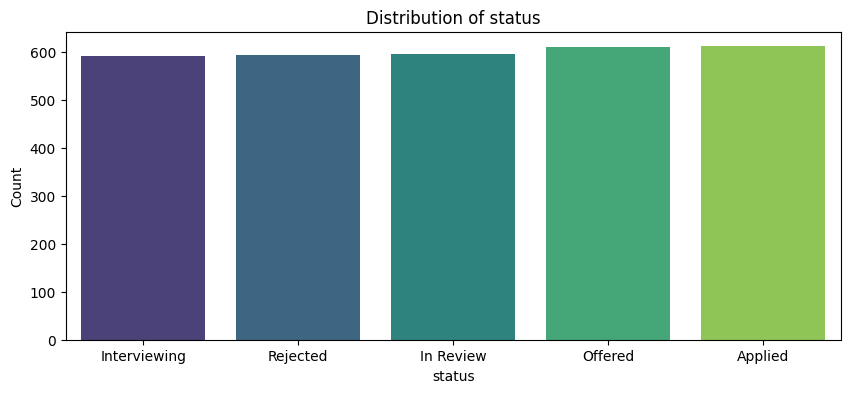

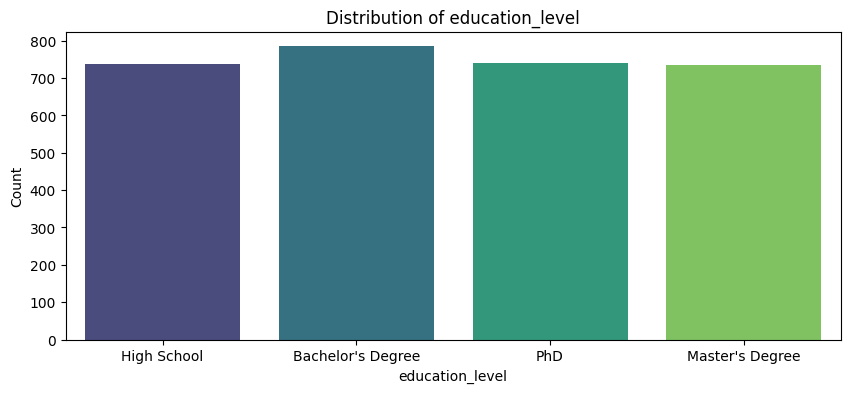

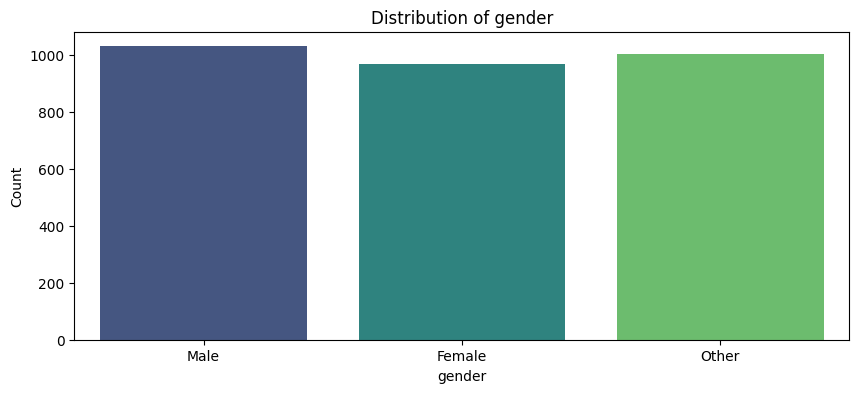

In [88]:
plot = ['status','education_level','gender']

for col in plot:
    plt.figure(figsize=(10,4))
    sns.countplot(data = df2, x = col, hue = col, palette='viridis')
    plt.title(f"Distribution of {col}")
    plt.ylabel('Count')
plt.show()


In [108]:
# df2['job_title'].unique()

In [99]:
top10 = df2['job_title'].value_counts().head(10).index

In [100]:
top10 = df2[df2['job_title'].isin(top10)]

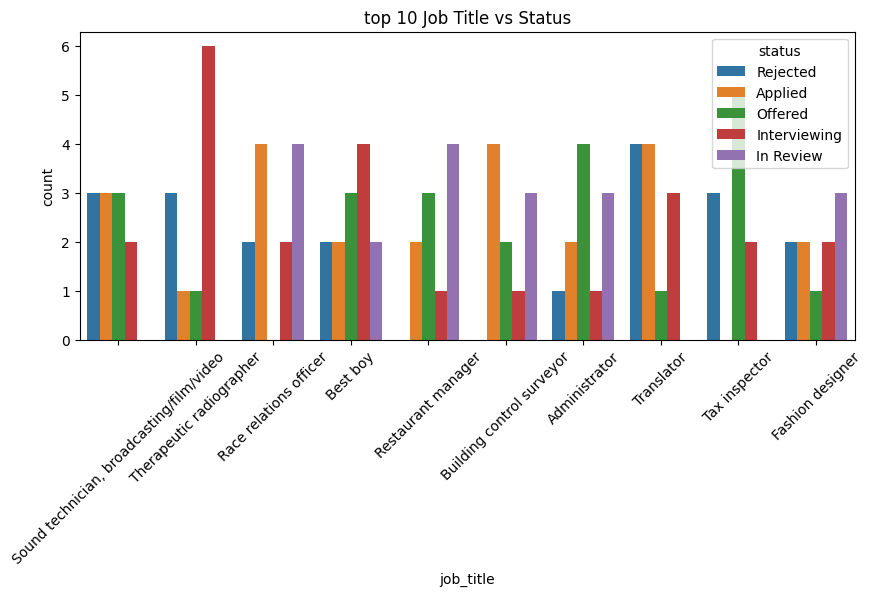

In [107]:
plt.figure(figsize=(10,4))
sns.countplot(data =top10, x = 'job_title', hue='status')
plt.xticks(rotation=45)
plt.title('top 10 Job Title vs Status')
# plt.tight_layout()
plt.show()

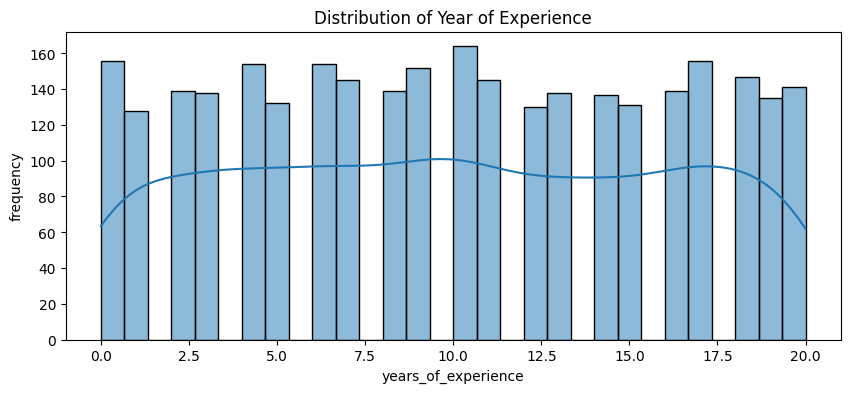

In [115]:
plt.figure(figsize=(10,4))
sns.histplot(data =df2, x='years_of_experience', bins=30, kde=True)
# plt.xticks(rotation=45)
plt.title('Distribution of Year of Experience')
plt.ylabel('frequency')
# plt.tight_layout()
plt.show()

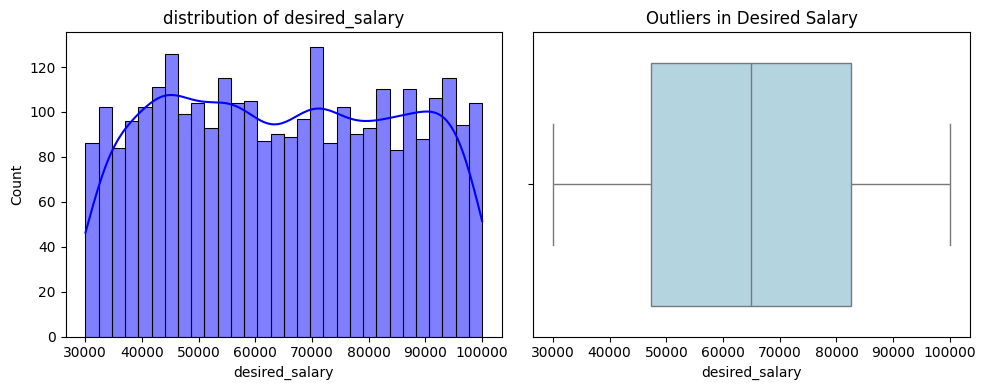

In [120]:
plt.figure(figsize=(10,4))
        # hisplot to check data distribution
plt.subplot(1,2,1)
sns.histplot(data =df2, x='desired_salary',bins = 30, kde=True,color = "blue")  
plt.title(f"distribution of desired_salary")

    # Boxplot fro oulier check
plt.subplot(1,2,2)
sns.boxplot(data = df2, x='desired_salary', color = "lightblue")
plt.title("Outliers in Desired Salary")
plt.tight_layout()
plt.show()


In [121]:
recruitment_clean = df2.copy()

In [122]:
recruitment_clean.to_csv('recruitment_clean.csv', index=False)

# employee_engagement_survey_data

In [123]:
df3 = pd.read_csv(r"C:\Users\ATHAR\Downloads\pwskills\HR Analytics\raw data\employee_engagement_survey_data.csv")
df3.head()

,Employee ID,Survey Date,Engagement Score,Satisfaction Score,Work-Life Balance Score
0,1001,10-10-2022,2,5,5
1,1002,03-08-2023,4,5,3
2,1003,03-01-2023,2,5,2
3,1004,30-07-2023,3,5,3
4,1005,19-06-2023,2,4,5


In [124]:
df3.shape

(3000, 5)

In [125]:
df3.isnull().sum()

Employee ID                0
Survey Date                0
Engagement Score           0
Satisfaction Score         0
Work-Life Balance Score    0
dtype: int64

In [127]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Employee ID              3000 non-null   int64 
 1   Survey Date              3000 non-null   object
 2   Engagement Score         3000 non-null   int64 
 3   Satisfaction Score       3000 non-null   int64 
 4   Work-Life Balance Score  3000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 117.3+ KB


In [129]:
df3.columns

Index(['Employee ID', 'Survey Date', 'Engagement Score', 'Satisfaction Score',
       'Work-Life Balance Score'],
      dtype='object')

In [130]:
df3.columns = df3.columns.str.lower().str.replace(' ', '_')

In [131]:
df3.columns

Index(['employee_id', 'survey_date', 'engagement_score', 'satisfaction_score',
       'work-life_balance_score'],
      dtype='object')

In [134]:
df3['survey_date'] = pd.to_datetime(df3['survey_date'], dayfirst=True)

In [135]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   employee_id              3000 non-null   int64         
 1   survey_date              3000 non-null   datetime64[ns]
 2   engagement_score         3000 non-null   int64         
 3   satisfaction_score       3000 non-null   int64         
 4   work-life_balance_score  3000 non-null   int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 117.3 KB


In [136]:
# EDA

In [140]:
num_col = df3.select_dtypes(include=['int64', 'float64'])
print(list(num_col))

['employee_id', 'engagement_score', 'satisfaction_score', 'work-life_balance_score']


In [148]:
num_plot = ['engagement_score','satisfaction_score','work-life_balance_score']

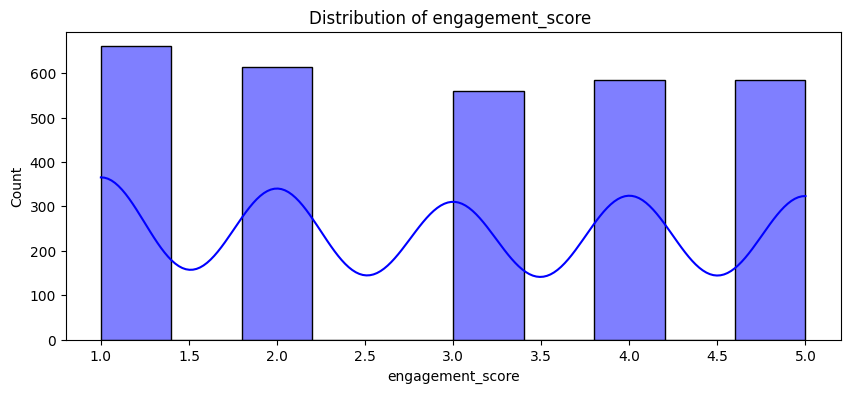

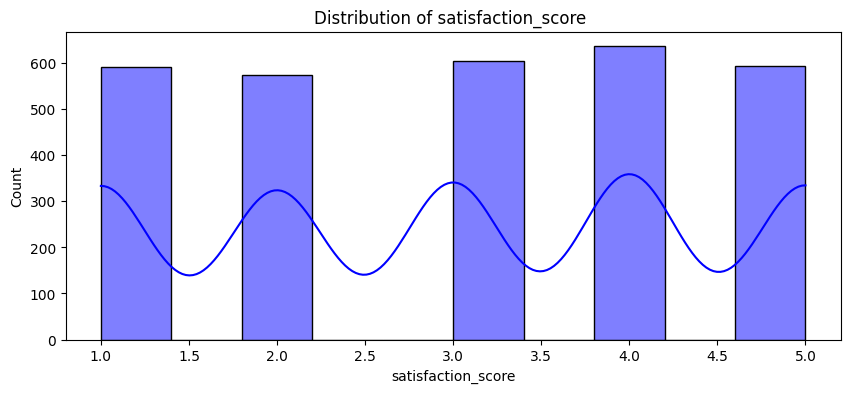

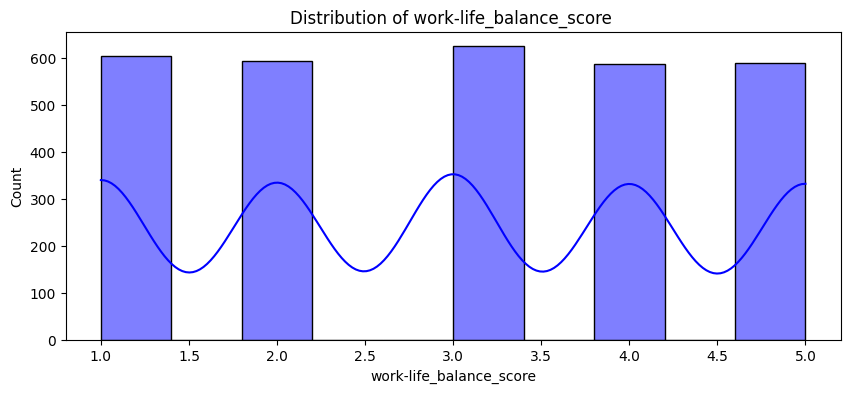

In [153]:
for col in num_plot:
    plt.figure(figsize = (10,4))
    sns.histplot(df3[col], bins = 10 ,kde=True, color='blue')
    plt.title(f"Distribution of {col} ")
    plt.show()

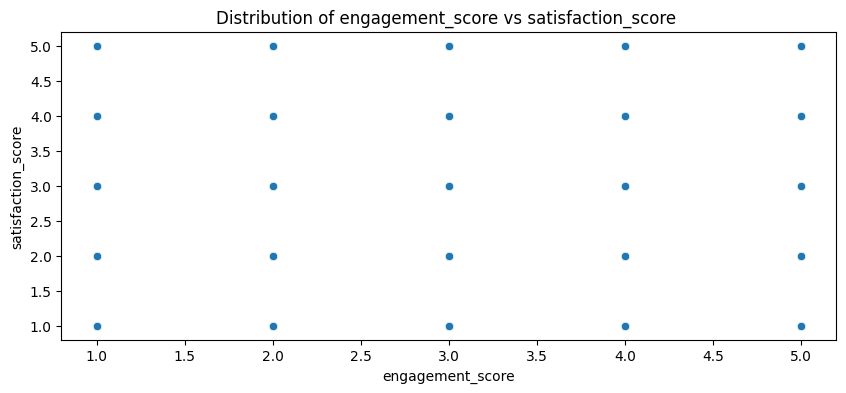

In [155]:
    plt.figure(figsize = (10,4))
    sns.scatterplot(data = df3,x ='engagement_score',y = 'satisfaction_score')
    plt.title(f"Distribution of engagement_score vs satisfaction_score ")
    plt.show()

In [156]:
engagement_clean = df3.copy()

In [158]:
engagement_clean.to_csv('engagement_clean.csv', index= False)

In [160]:
# pushing df_clean inot database

from sqlalchemy import create_engine

# Define connection variables
db_host = "localhost"
db_user = "root"
db_password = "Athar123#"
db_name = "hr_analytics"
db_port = 3306

# Create the database connection engine
connection_string = f"mysql+pymysql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
engine = create_engine(connection_string)

print("Successfully connected to the database!")



Successfully connected to the database!


In [164]:
tables_to_upload = {
    'training_data': training_clean,
    'recruitment_data': recruitment_clean,
    'engagement_data': engagement_clean
}

for table_name, dataframe in tables_to_upload.items():
    dataframe.to_sql(
        name = table_name,
        con = engine,
        if_exists='replace',
        chunksize= 1000,   # use to fast upload if there is 50k row or more
        method= 'multi',  # speed bulk database insert
        index = False
    )

    print(f"Uploaded successfully: '{table_name}'")


Uploaded successfully: 'training_data'
Uploaded successfully: 'recruitment_data'
Uploaded successfully: 'engagement_data'
